# NCI-60 Human Tumor Cell Lines Screen

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools as itt
import tqdm.auto as tqdm

The inhibition data is available [online](https://wiki.nci.nih.gov/spaces/NCIDTPdata/pages/147193864/NCI-60+Growth+Inhibition+Data) (Feb 10, 2025)

In [42]:
df = pd.read_csv("../data/raw/IC50.csv")
# df = pd.read_csv('~/Downloads/GI50.csv')
df

,RELEASE_DATE,EXPID,PREFIX,NSC,CONCENTRATION_UNIT,LOG_HI_CONCENTRATION,PANEL_NUMBER,CELL_NUMBER,PANEL_NAME,CELL_NAME,PANEL_CODE,COUNT,AVERAGE,STDDEV
0,20210223,0001MD02,S,123127,M,-4.6021,10,20,Melanoma,UACC-62,MEL,1,-6.8434,0.0
1,20210223,0001MD02,S,123127,M,-4.6021,10,21,Melanoma,UACC-257,MEL,1,-6.1932,0.0
2,20210223,0001MD02,S,123127,M,-4.6021,11,1,Prostate Cancer,PC-3,PRO,1,-6.3816,0.0
3,20210223,0001MD02,S,123127,M,-4.6021,12,2,CNS Cancer,SNB-19,CNS,1,-7.0474,0.0
4,20210223,0001MD02,S,123127,M,-4.6021,4,1,Colon Cancer,HT29,COL,1,-6.4681,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4753379,20241231,2208RS46,S,833487,M,-4.0000,5,1,Breast Cancer,MCF7,BRE,1,-7.1269,0.0
4753380,20241231,2208RS46,S,833487,M,-4.0000,5,6,Breast Cancer,HS 578T,BRE,1,-4.0000,0.0
4753381,20241231,2208RS46,S,833487,M,-4.0000,6,11,Ovarian Cancer,SK-OV-3,OVA,1,-4.0000,0.0
4753382,20241231,2208RS46,S,833487,M,-4.0000,9,15,Renal Cancer,CAKI-1,REN,1,-4.0000,0.0


The SMILES are available [online](https://wiki.nci.nih.gov/spaces/NCIDTPdata/pages/155844992/Chemical+Data) (Feb 10, 2025)

In [26]:
smiles = pd.read_csv("../data/raw/nsc_smiles.csv")
smiles = smiles[
    ~smiles["NSC"].isna() & ~smiles["SMILES"].isna()
]  # remove ill-formed entries: missing SMILES or NSC ident
smiles = smiles.astype({"NSC": int})
smiles

,NSC,SMILES
0,1,CC1=CC(=O)C=CC1=O
1,2,S(Sc1nc2ccccc2s1)c3nc4ccccc4s3
2,3,Oc1c(Cl)cc(cc1[N+](=O)[O-])[N+](=O)[O-]
3,4,Nc1ncc(s1)[N+](=O)[O-]
4,5,Nc1ccc2C(=O)c3ccccc3C(=O)c2c1
...,...,...
325422,855177,COc1nc(C)cc(O[C@@H]2CC[C@H](N)C2)c1c3cc(Nc4cnc...
325423,855286,O.O.NC1=NC(=C(CC(=O)Nc2cnc(C(=O)N[C@@H](CCC(=O...
325424,855361,CCN1C(=NN(C1=O)c2cc3C(=CN(C(=O)c3cc2F)c4ccccc4...
325425,855373,Cc1c(oc2c(F)cc(F)cc12)[C@@H](NC(=O)Nc3cnc(N)nc...


In [27]:
df = df.merge(smiles, how="inner")
df

,RELEASE_DATE,EXPID,PREFIX,NSC,CONCENTRATION_UNIT,LOG_HI_CONCENTRATION,PANEL_NUMBER,CELL_NUMBER,PANEL_NAME,CELL_NAME,PANEL_CODE,COUNT,AVERAGE,STDDEV,SMILES
0,20210223,0001MD02,S,123127,M,-4.6021,1,1,Non-Small Cell Lung Cancer,NCI-H23,LNS,1,-7.1391,0.0,COc1cccc2C(=O)c3c(O)c4C[C@](O)(C[C@H](OC5CC(N)...
1,20210223,0001MD02,S,123127,M,-4.6021,10,14,Melanoma,M14,MEL,1,-7.0520,0.0,COc1cccc2C(=O)c3c(O)c4C[C@](O)(C[C@H](OC5CC(N)...
2,20210223,0001MD02,S,123127,M,-4.6021,12,5,CNS Cancer,SNB-75,CNS,1,-7.1380,0.0,COc1cccc2C(=O)c3c(O)c4C[C@](O)(C[C@H](OC5CC(N)...
3,20210223,0001MD02,S,123127,M,-4.6021,4,2,Colon Cancer,HCC-2998,COL,1,-6.9426,0.0,COc1cccc2C(=O)c3c(O)c4C[C@](O)(C[C@H](OC5CC(N)...
4,20210223,0001MD02,S,123127,M,-4.6021,5,5,Breast Cancer,MDA-MB-231/ATCC,BRE,1,-6.4485,0.0,COc1cccc2C(=O)c3c(O)c4C[C@](O)(C[C@H](OC5CC(N)...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4692801,20241231,2208RS46,S,833058,M,-4.0000,7,3,Leukemia,CCRF-CEM,LEU,1,-6.5614,0.0,COc1cccc(c1)C(=N)Nc2ccc(OCCCCCCCCn3cnnn3)c(C)c2
4692802,20241231,2208RS46,S,833487,M,-4.0000,10,14,Melanoma,M14,MEL,1,-4.7828,0.0,CC\C(=C(\c1ccc(O)cc1)/c2ccc(OCCN(C)C(=O)COCCOC...
4692803,20241231,2208RS46,S,833487,M,-4.0000,5,1,Breast Cancer,MCF7,BRE,1,-7.4347,0.0,CC\C(=C(\c1ccc(O)cc1)/c2ccc(OCCN(C)C(=O)COCCOC...
4692804,20241231,2208RS46,S,833487,M,-4.0000,5,6,Breast Cancer,HS 578T,BRE,1,-5.8759,0.0,CC\C(=C(\c1ccc(O)cc1)/c2ccc(OCCN(C)C(=O)COCCOC...


We will ignore uncommon measurement units for simplicity.

<Axes: >

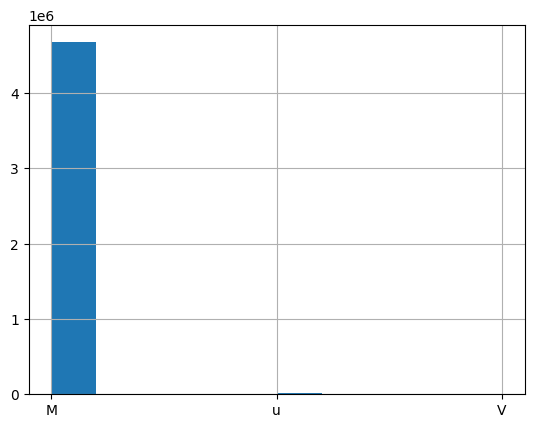

In [28]:
df["CONCENTRATION_UNIT"].hist()

In [29]:
df = df[df["CONCENTRATION_UNIT"] == "M"]

We check for the cellular targets with the largest coverage.

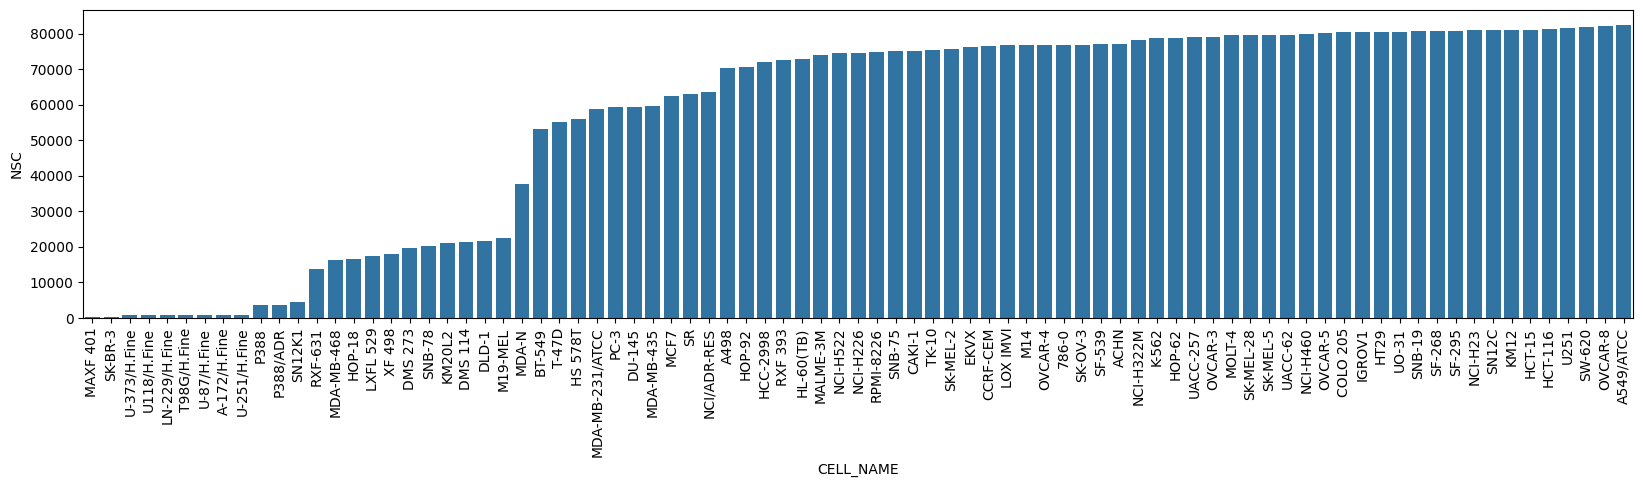

In [30]:
common_cells = df.groupby("CELL_NAME").count()[["NSC"]].reset_index().sort_values("NSC")
common_cells = common_cells[common_cells["NSC"] > 100]

_, ax = plt.subplots(figsize=(20, 4))
sns.barplot(
    data=common_cells,
    x="CELL_NAME",
    y="NSC",
    ax=ax,
)
locs, labels = plt.xticks()
plt.setp(labels, rotation=90);

We select a cell line with large coverage. This way we don't have to worry about encoding the cell.

In [31]:
target = "A549/ATCC"
atcc = df[df["CELL_NAME"] == target].copy()
print(f"{len(atcc)} data points")
atcc.describe()

82573 data points


,RELEASE_DATE,NSC,LOG_HI_CONCENTRATION,PANEL_NUMBER,CELL_NUMBER,COUNT,AVERAGE,STDDEV
count,8.257300e+04,82573.000000,82573.000000,82573.0,82573.0,82573.000000,82573.000000,82573.000000
mean,2.021107e+07,548556.271784,-4.035179,1.0,4.0,1.000036,-5.042706,0.000008
std,4.498909e+03,256290.694281,0.511242,0.0,0.0,0.006027,1.203650,0.002428
min,2.021022e+07,1.000000,-12.699000,1.0,4.0,1.000000,-15.355200,0.000000
25%,2.021022e+07,367334.000000,-4.000000,1.0,4.0,1.000000,-5.679500,0.000000
50%,2.021022e+07,658156.000000,-4.000000,1.0,4.0,1.000000,-4.689600,0.000000
75%,2.021022e+07,707832.000000,-4.000000,1.0,4.0,1.000000,-4.000000,0.000000
max,2.024123e+07,849222.000000,4.000000,1.0,4.0,2.000000,4.000000,0.697700


In [32]:
atcc.head()

,RELEASE_DATE,EXPID,PREFIX,NSC,CONCENTRATION_UNIT,LOG_HI_CONCENTRATION,PANEL_NUMBER,CELL_NUMBER,PANEL_NAME,CELL_NAME,PANEL_CODE,COUNT,AVERAGE,STDDEV,SMILES
21,20210223,0001MD05,S,123127,M,-4.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,-6.8794,0.0,COc1cccc2C(=O)c3c(O)c4C[C@](O)(C[C@H](OC5CC(N)...
57,20210223,0001MD05,S,713733,M,-4.0000,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,-4.6081,0.0,CN1N=C(OCC(O)CN2CCN(CC2)c3ccccc3)c4c(C)n(c(C)c...
64,20210223,0001MD05,S,713736,M,-4.0000,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,-4.6840,0.0,CN1N=C(OCCCCN2CCN(CC2)c3ncccn3)c4c(C)n(c(C)c4C...
131,20210223,0001MD05,S,713827,M,-4.0000,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,-5.1443,0.0,COc1cc(\C=C\2/CC3C4CC[C@H]5C[C@@H](O)CC[C@]5(C...
191,20210223,0001MD03,S,19893,M,-2.6021,1,4,Non-Small Cell Lung Cancer,A549/ATCC,LNS,1,-5.0082,0.0,FC1=CNC(=O)NC1=O


In [33]:
atcc.nunique()

RELEASE_DATE               17
EXPID                    4996
PREFIX                      1
NSC                     56353
CONCENTRATION_UNIT          1
LOG_HI_CONCENTRATION      291
PANEL_NUMBER                1
CELL_NUMBER                 1
PANEL_NAME                  1
CELL_NAME                   1
PANEL_CODE                  1
COUNT                       2
AVERAGE                 26952
STDDEV                      2
SMILES                  55483
dtype: int64

In [34]:
assay_stats = atcc.groupby("EXPID")[["NSC"]].nunique().sort_values("NSC")
assay_stats

,NSC
EXPID,
0709RS06,1
9310SC05,1
9311BC80,1
9311BC82,1
9311BG14,1
...,...
1108NS08,89
1210NS67,90
1103NS08,90


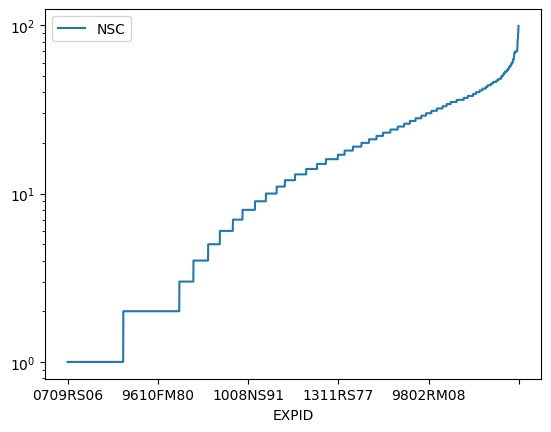

In [35]:
assay_stats.plot()
plt.yscale("log")

`LOG_HI_CONCENTRATION` is the highest concentration tested. Therefore, if `AVERAGE`, in this case IC50, is larger or equal, we are dealing with censored data.

In [36]:
censored = atcc["AVERAGE"] >= atcc["LOG_HI_CONCENTRATION"]
atcc["CENSORED"] = censored
censored.mean(), censored.sum()

(np.float64(0.3333050755089436), np.int64(27522))

<Axes: ylabel='Density'>

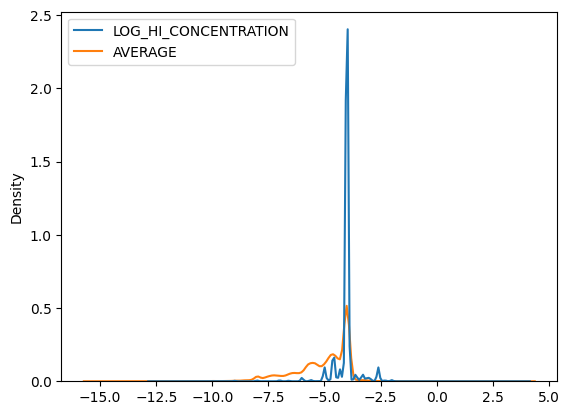

In [37]:
sns.kdeplot(atcc[["LOG_HI_CONCENTRATION", "AVERAGE"]])
# plt.yscale('log')

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


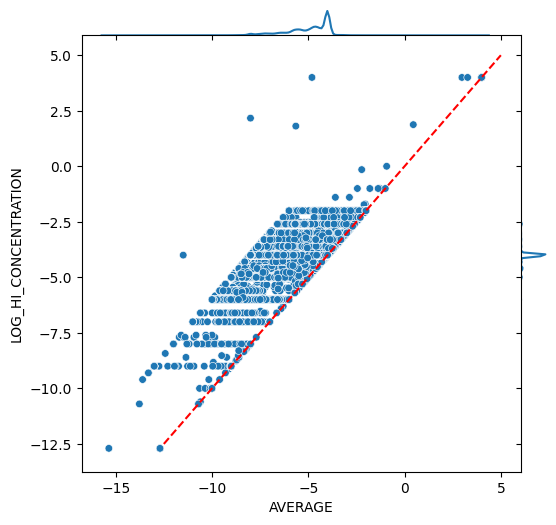

In [38]:
g = sns.JointGrid(data=atcc, x="AVERAGE", y="LOG_HI_CONCENTRATION", space=0, ratio=17)
g.plot_joint(sns.scatterplot, sizes=(30, 120), size=5, legend=False)
g.plot_marginals(sns.kdeplot)
g.ax_joint.plot([-12.5, 5], [-12.5, 5], "r--")

# g.ax_joint.plot([-12.5 - 4, (-4) + 5], [-12.5 + 4.2 - 4, (-4) + 5 + 4.2], "r--")

Let's take a look at temporal shift in activity.

In [39]:
atcc["DATE_ORDER"] = atcc["RELEASE_DATE"].map(
    {d: i for i, d in enumerate(sorted(atcc["RELEASE_DATE"].unique()))}.get
)

/home/michael/Code/hodge-dti/.venv/lib/python3.12/site-packages/seaborn/axisgrid.py:1766: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  f.tight_layout()


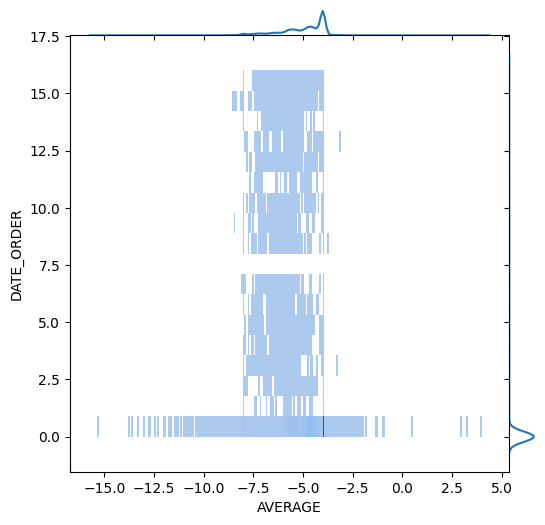

In [40]:
g = sns.JointGrid(data=atcc, x="AVERAGE", y="DATE_ORDER", space=0, ratio=17)
g.plot_joint(sns.histplot)
g.plot_marginals(sns.kdeplot)

In [41]:
atcc["CELL_NUMBER"].unique()

array([4])

Overlap between experiments.

In [19]:
group_sets = df.groupby("EXPID")["NSC"].apply(frozenset).to_dict()

pairwise_intersections = {
    (g1, g2): group_sets[g1] & group_sets[g2]
    for g1, g2 in tqdm.tqdm(itt.combinations(group_sets, 2))
}

0it [00:00, ?it/s]

In [20]:
pairwise_intersections

{('0001MD02', '0001MD03'): frozenset({19893}),
 ('0001MD02', '0001MD05'): frozenset({19893, 123127}),
 ('0001MD02', '0001MD07'): frozenset({19893, 123127}),
 ('0001MD02', '0001MD08'): frozenset({19893, 123127}),
 ('0001MD02', '0001MD10'): frozenset({19893, 123127}),
 ('0001MD02', '0001NS02'): frozenset({19893}),
 ('0001MD02', '0001NS03'): frozenset({123127}),
 ('0001MD02', '0001NS04'): frozenset({19893}),
 ('0001MD02', '0001NS05'): frozenset({19893, 123127}),
 ('0001MD02', '0001NS06'): frozenset({123127}),
 ('0001MD02', '0001NS07'): frozenset({19893}),
 ('0001MD02', '0001NS08'): frozenset({19893, 123127}),
 ('0001MD02', '0001NS10'): frozenset({19893, 123127}),
 ('0001MD02', '0001RM03'): frozenset({123127}),
 ('0001MD02', '0001RM06'): frozenset(),
 ('0001MD02', '0001RS02'): frozenset({123127}),
 ('0001MD02', '0002BM13'): frozenset({123127}),
 ('0001MD02', '0002BS14'): frozenset({123127}),
 ('0001MD02', '0002MD09'): frozenset({19893, 123127}),
 ('0001MD02', '0002MD11'): frozenset({19893,

In [21]:
from rdkit import Chem

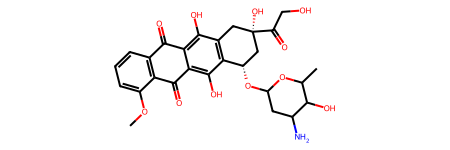

In [22]:
Chem.MolFromSmiles(smiles.set_index("NSC").loc[123127, "SMILES"])

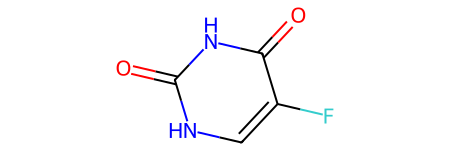

In [23]:
Chem.MolFromSmiles(smiles.set_index("NSC").loc[19893, "SMILES"])

In [24]:
atcc.to_csv("../data/raw/atcc.csv")